### WIP Visualizer for corridor case

141.4213562373095


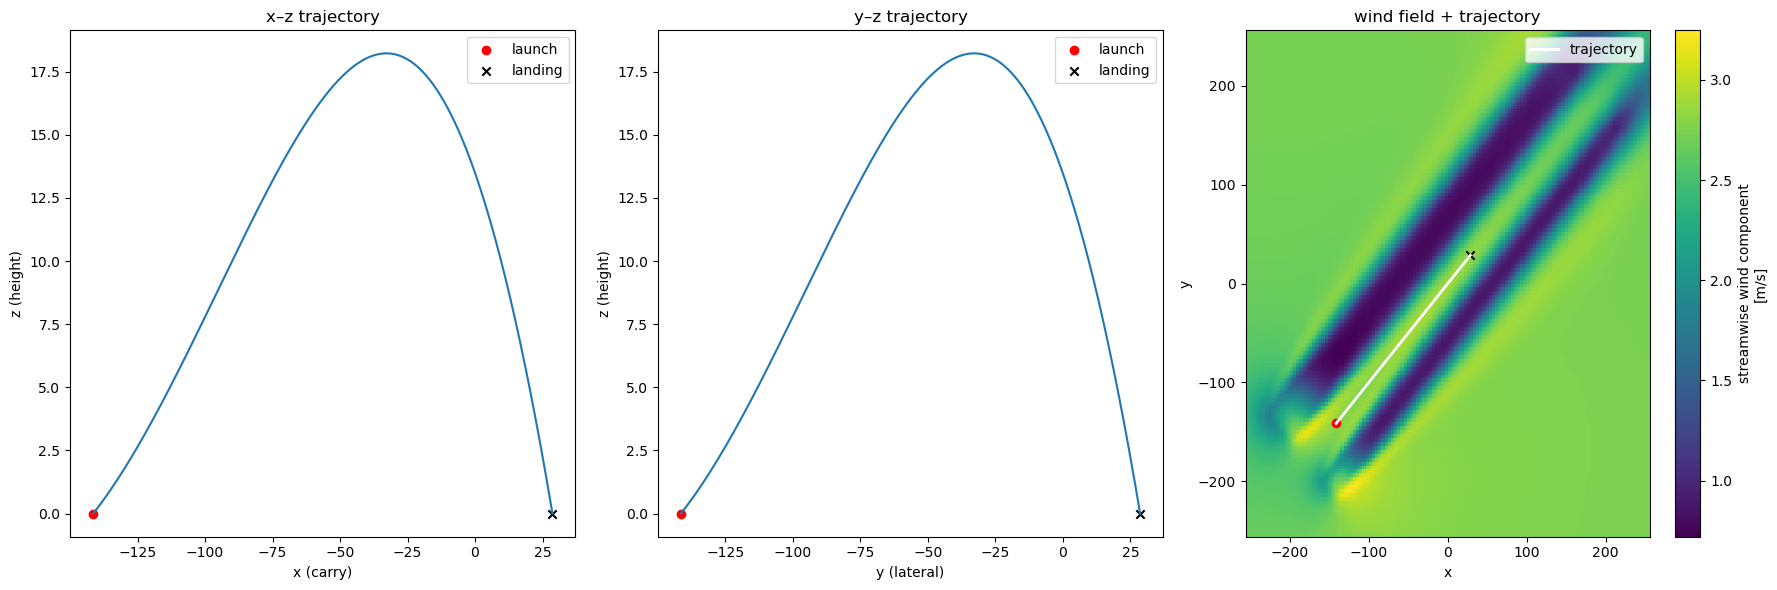

In [ ]:
# Looking at the corridor case
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from Tracer import WindField, Trajectory
from Tracer.solvers import solver_rk45, solver_euler
import xarray as xr

filepath = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_corr_wd225.nc'

U_ref = 6
r = 100
corr_wf = WindField(profile='rans',ds=filepath, U_ref=U_ref)

dist = np.sqrt(r**2 +r**2)
print(dist)

# play field parameters - these make up the baseline shot
P0=np.array([-dist, -dist, 0])
dt = 0.01       # time step

# Basis shot parameters - if not otherwise specified, these are used
shot_speed = 76.44384   # intital velocity
shot_angle = 5.4       # initial angle for trajectory	
shot_spin = 2545        # initial spin
spin_axis = 0           # spin axis adding impurity to the spin
orientation = 45        # play direction

# Basis wind parameters - if not otherwise specified, these are used
U_ref = 6      # reference wind speed at 10 meters above ground (6 m/s is approx. danish average)
z0 = 0.03       # surface roughness
direction = 351   # wind direction (0 is tailwind, 180 is headwind)

# script parameters
design_n = 10           # design parameter for # of values in design library
r = 150                 # Approximate radius of playfield, used for rotation and movement of player position

wind = corr_wf

traj = Trajectory(
        ball_speed=shot_speed,
        launch_angle=shot_angle,
        spin_rate=shot_spin,
        spin_axis=spin_axis,
        wind=wind,
        orientation=orientation,
        P0=P0
    )
traj.solve(solver='euler', dt=dt)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# =========================
# LEFT: X-Z (CARRY PROFILE)
# =========================
ax[0].plot(traj.p[:, 0], traj.p[:, 2])

ax[0].scatter(traj.p[0, 0], traj.p[0, 2],
              color='red', label='launch')

ax[0].scatter(traj.p[-1, 0], traj.p[-1, 2],
              color='black', marker='x', label='landing')

ax[0].set_xlabel('x (carry)')
ax[0].set_ylabel('z (height)')
ax[0].set_title('x–z trajectory')
ax[0].legend()

# =========================
# MIDDLE: Y-Z (SIDE DRIFT)
# =========================
ax[1].plot(traj.p[:, 1], traj.p[:, 2])

ax[1].scatter(traj.p[0, 1], traj.p[0, 2],
              color='red', label='launch')

ax[1].scatter(traj.p[-1, 1], traj.p[-1, 2],
              color='black', marker='x', label='landing')

ax[1].set_xlabel('y (lateral)')
ax[1].set_ylabel('z (height)')
ax[1].set_title('y–z trajectory')
ax[1].legend()

# =========================
# RIGHT: XY HEATMAP + OVERLAY
# =========================
U_slice = corr_wf.ds.U.isel(z=10)

U_slice.plot(
    x="x",
    y="y",
    ax=ax[2],
    cmap="viridis",
    add_colorbar=True
)

ax[2].plot(traj.p[:, 0], traj.p[:, 1],
           color='white', linewidth=2, label='trajectory')

ax[2].scatter(traj.p[0, 0], traj.p[0, 1],
              color='red')

ax[2].scatter(traj.p[-1, 0], traj.p[-1, 1],
              color='black', marker='x')

ax[2].set_xlim(-256, 256)
ax[2].set_ylim(-256, 256)
ax[2].set_xlabel('x')
ax[2].set_ylabel('y')
ax[2].set_title('wind field + trajectory')
ax[2].legend()

plt.tight_layout()
plt.show()

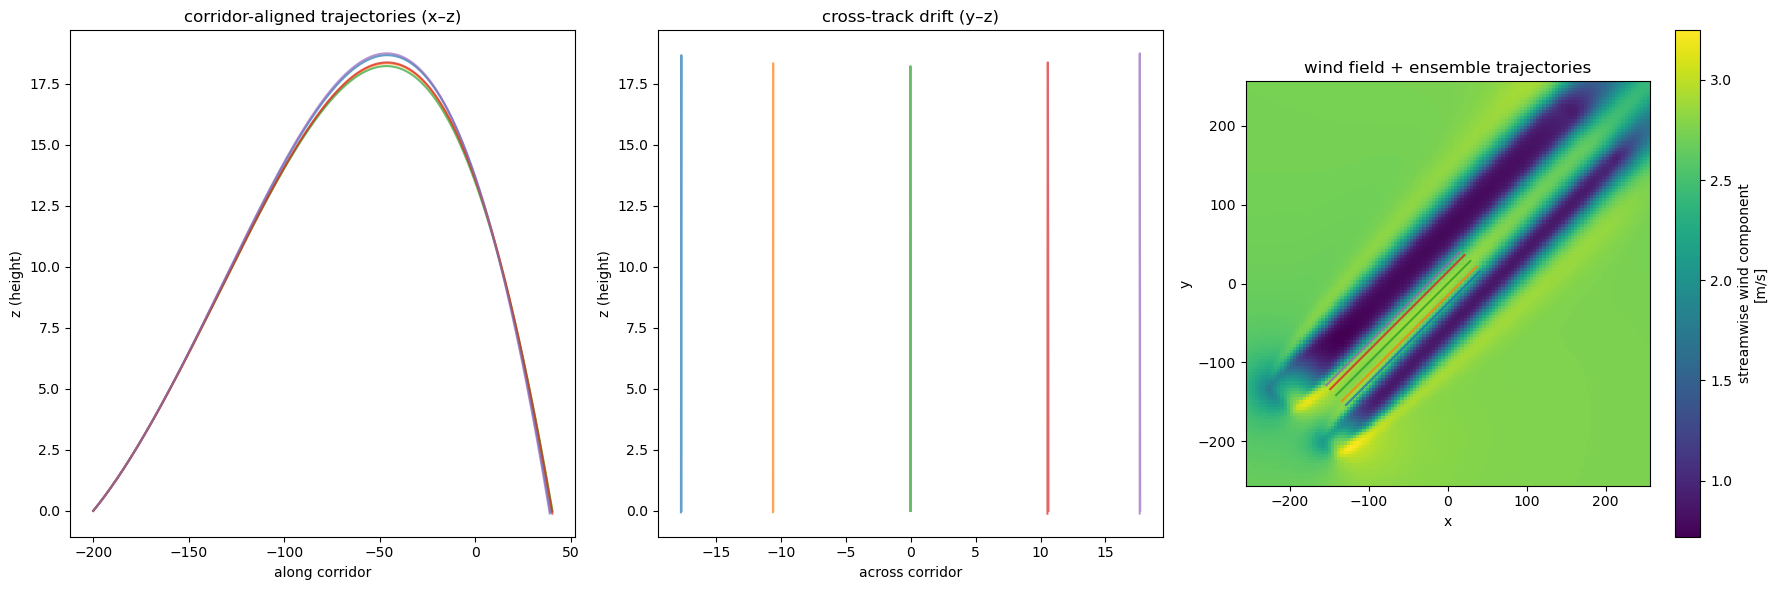

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from Tracer import WindField, Trajectory
import xarray as xr

filepath = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_corr_wd225.nc'

# -----------------------
# Parameters
# -----------------------
U_ref = 6
r = 100
corr_wf = WindField(profile='rans', ds=filepath, U_ref=U_ref)

dist = np.sqrt(r**2 + r**2)

P0_base = np.array([-dist, -dist, 0])
dt = 0.01

shot_speed = 76.44384
shot_angle = 5.4
shot_spin = 2545
spin_axis = 0
orientation = 45

# -----------------------
# Corridor start positions (lateral offsets)
# -----------------------
rel_corr_pos_values = [-25, -15, 0, 15, 25]

trajectories = []

# -----------------------
# Run ensemble
# -----------------------
for i in range(len(rel_corr_pos_values)):

    component = rel_corr_pos_values[i] / 2
    # shift start position in global frame
    P0 = np.array([-dist - component, -dist + component, 0])

    traj = Trajectory(
        ball_speed=shot_speed,
        launch_angle=shot_angle,
        spin_rate=shot_spin,
        spin_axis=spin_axis,
        wind=corr_wf,
        orientation=orientation,
        P0=P0
    )

    traj.solve(solver='euler', dt=dt)
    trajectories.append(traj)

# -----------------------
# Plot setup
# -----------------------
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

sqrt2 = np.sqrt(2)

# =========================
# LEFT: x-z
# =========================
for traj in trajectories:
    x = traj.p[:, 0]
    y = traj.p[:, 1]
    z = traj.p[:, 2]

    x_corr = (x + y) / sqrt2
    ax[0].plot(x_corr, z, alpha=0.7)

ax[0].set_xlabel('along corridor')
ax[0].set_ylabel('z (height)')
ax[0].set_title('corridor-aligned trajectories (x–z)')

# =========================
# MIDDLE: y-z (drift)
# =========================
for traj in trajectories:
    x = traj.p[:, 0]
    y = traj.p[:, 1]
    z = traj.p[:, 2]

    y_corr = (y - x) / sqrt2
    ax[1].plot(y_corr, z, alpha=0.7)

ax[1].set_xlabel('across corridor')
ax[1].set_ylabel('z (height)')
ax[1].set_title('cross-track drift (y–z)')

# =========================
# RIGHT: wind field + trajectories
# =========================
U_slice = corr_wf.ds.U.isel(z=10)

U_slice.plot(
    x="x",
    y="y",
    ax=ax[2],
    cmap="viridis",
    add_colorbar=True
)

for i, traj in enumerate(trajectories):
    ax[2].plot(traj.p[:, 0], traj.p[:, 1], alpha=0.8)

ax[2].set_xlim(-256, 256)
ax[2].set_ylim(-256, 256)
ax[2].set_aspect('equal', adjustable='box')
ax[2].set_xlabel('x')
ax[2].set_ylabel('y')
ax[2].set_title('wind field + ensemble trajectories')

plt.tight_layout()
plt.show()

141.4213562373095


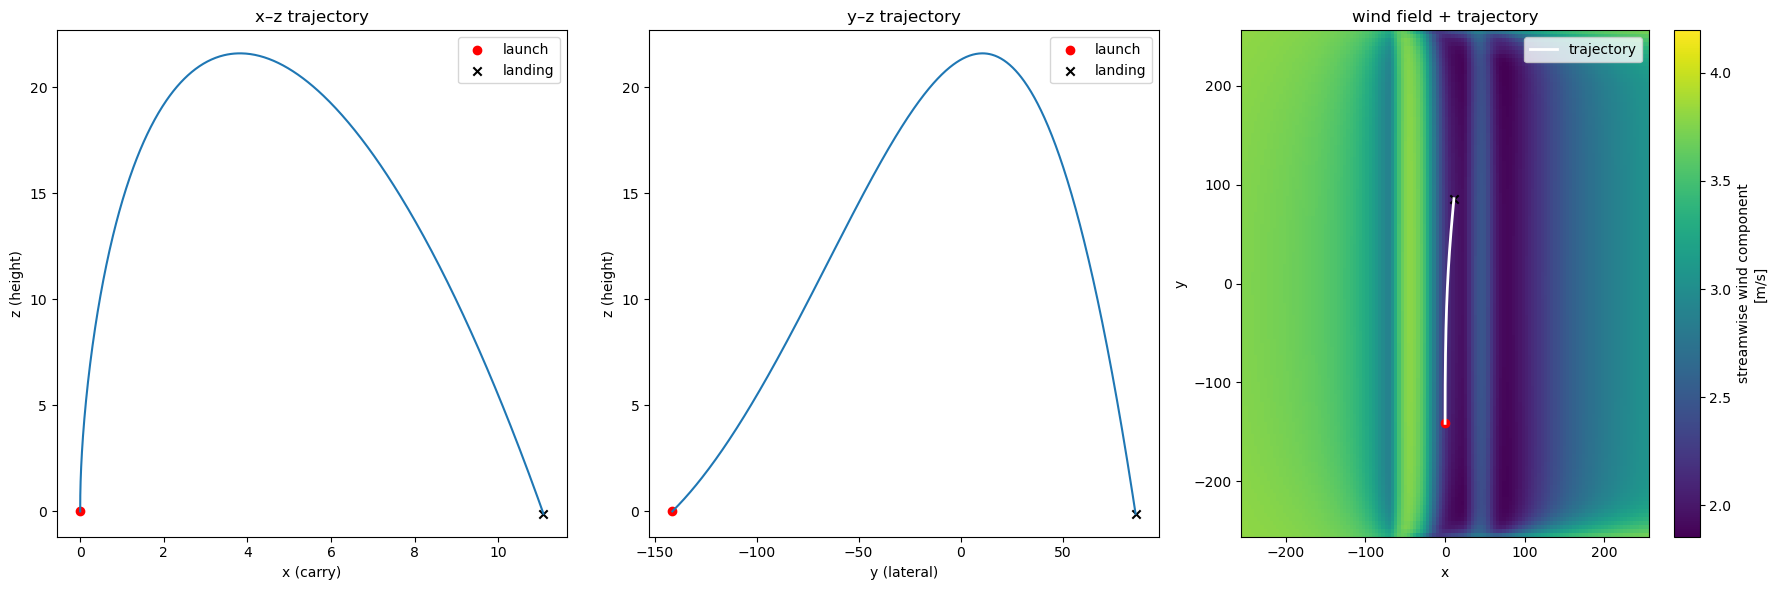

In [236]:
# Looking at the corridor case
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from Tracer import WindField, Trajectory
from Tracer.solvers import solver_rk45, solver_euler
import xarray as xr

filepath = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_corr_wd270.nc'

U_ref = 6
r = 100
corr_wf = WindField(profile='rans',ds=filepath, U_ref=U_ref)

dist = np.sqrt(r**2 +r**2)
print(dist)

# play field parameters - these make up the baseline shot
P0_base = np.array([0, -r, 0])
dt = 0.01       # time step

# Basis shot parameters - if not otherwise specified, these are used
shot_speed = 76.44384   # intital velocity
shot_angle = 5.4       # initial angle for trajectory	
shot_spin = 2545        # initial spin
spin_axis = 0           # spin axis adding impurity to the spin
orientation = 90        # play direction

# Basis wind parameters - if not otherwise specified, these are used
U_ref = 6      # reference wind speed at 10 meters above ground (6 m/s is approx. danish average)
z0 = 0.03       # surface roughness
direction = 351   # wind direction (0 is tailwind, 180 is headwind)

# script parameters
design_n = 10           # design parameter for # of values in design library
r = 150                 # Approximate radius of playfield, used for rotation and movement of player position

wind = corr_wf

traj = Trajectory(
        ball_speed=shot_speed,
        launch_angle=shot_angle,
        spin_rate=shot_spin,
        spin_axis=spin_axis,
        wind=wind,
        orientation=orientation,
        P0=P0
    )
traj.solve(solver='euler', dt=dt)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# =========================
# LEFT: X-Z (CARRY PROFILE)
# =========================
ax[0].plot(traj.p[:, 0], traj.p[:, 2])

ax[0].scatter(traj.p[0, 0], traj.p[0, 2],
              color='red', label='launch')

ax[0].scatter(traj.p[-1, 0], traj.p[-1, 2],
              color='black', marker='x', label='landing')

ax[0].set_xlabel('x (carry)')
ax[0].set_ylabel('z (height)')
ax[0].set_title('x–z trajectory')
ax[0].legend()

# =========================
# MIDDLE: Y-Z (SIDE DRIFT)
# =========================
ax[1].plot(traj.p[:, 1], traj.p[:, 2])

ax[1].scatter(traj.p[0, 1], traj.p[0, 2],
              color='red', label='launch')

ax[1].scatter(traj.p[-1, 1], traj.p[-1, 2],
              color='black', marker='x', label='landing')

ax[1].set_xlabel('y (lateral)')
ax[1].set_ylabel('z (height)')
ax[1].set_title('y–z trajectory')
ax[1].legend()

# =========================
# RIGHT: XY HEATMAP + OVERLAY
# =========================
U_slice = corr_wf.ds.U.isel(z=10)

U_slice.plot(
    x="x",
    y="y",
    ax=ax[2],
    cmap="viridis",
    add_colorbar=True
)

ax[2].plot(traj.p[:, 0], traj.p[:, 1],
           color='white', linewidth=2, label='trajectory')

ax[2].scatter(traj.p[0, 0], traj.p[0, 1],
              color='red')

ax[2].scatter(traj.p[-1, 0], traj.p[-1, 1],
              color='black', marker='x')

ax[2].set_xlim(-256, 256)
ax[2].set_ylim(-256, 256)
ax[2].set_xlabel('x')
ax[2].set_ylabel('y')
ax[2].set_title('wind field + trajectory')
ax[2].legend()

plt.tight_layout()
plt.show()

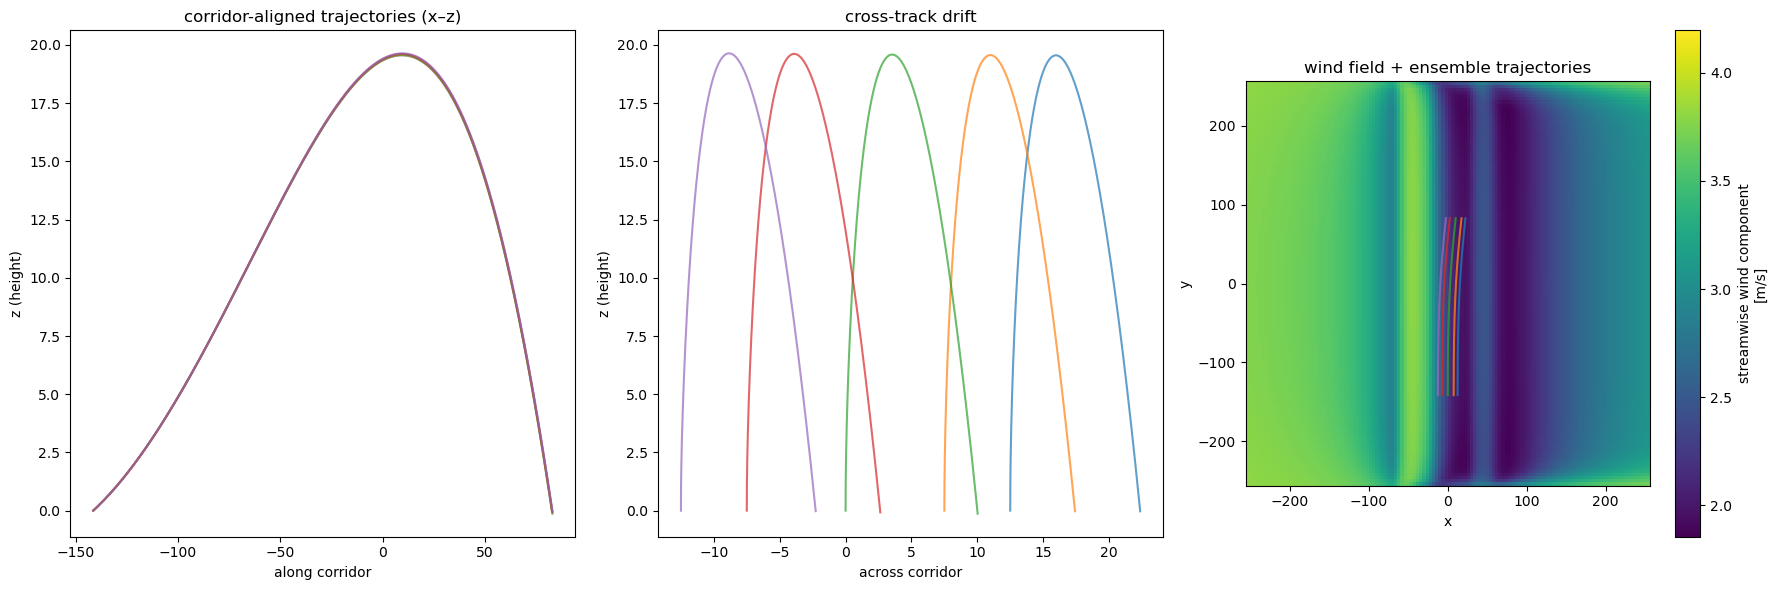

In [237]:
# WIP
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from Tracer import WindField, Trajectory
import xarray as xr

filepath = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_corr_wd270.nc'

# -----------------------
# Parameters
# -----------------------
U_ref = 6
r = 100
corr_wf = WindField(profile='rans', ds=filepath, U_ref=U_ref)

dist = np.sqrt(r**2 + r**2)

P0_base = np.array([0, -r, 0])
dt = 0.01

shot_speed = 76.44384
shot_angle = 4.6
shot_spin = 2545
spin_axis = 0
orientation = 90

# -----------------------
# Corridor start positions (lateral offsets)
# -----------------------
rel_corr_pos_values = [-25, -15, 0, 15, 25]

trajectories = []

# -----------------------
# Run ensemble
# -----------------------
for i in range(len(rel_corr_pos_values)):

    component = rel_corr_pos_values[i] / 2
    # shift start position in global frame
    P0 = np.array([-component, -dist, 0])

    traj = Trajectory(
        ball_speed=shot_speed,
        launch_angle=shot_angle,
        spin_rate=shot_spin,
        spin_axis=spin_axis,
        wind=corr_wf,
        orientation=orientation,
        P0=P0
    )

    traj.solve(solver='euler', dt=dt)
    trajectories.append(traj)

# -----------------------
# Plot setup
# -----------------------
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# =========================
# LEFT: Along corridor (y,z)
# =========================
for traj in trajectories:
    ax[0].plot(traj.p[:,1], traj.p[:,2], alpha=0.7)

ax[0].set_xlabel('along corridor')
ax[0].set_ylabel('z (height)')
ax[0].set_title('corridor-aligned trajectories (x–z)')

# =========================
# MIDDLE: sideways drift (x,z)
# =========================
for traj in trajectories:

    ax[1].plot(traj.p[:,0], traj.p[:,2], alpha=0.7)

ax[1].set_xlabel('across corridor')
ax[1].set_ylabel('z (height)')
ax[1].set_title('cross-track drift')

# =========================
# RIGHT: wind field + trajectories
# =========================
U_slice = corr_wf.ds.U.isel(z=10)

U_slice.plot(
    x="x",
    y="y",
    ax=ax[2],
    cmap="viridis",
    add_colorbar=True
)

for i, traj in enumerate(trajectories):
    ax[2].plot(traj.p[:, 0], traj.p[:, 1], alpha=0.8)

ax[2].set_xlim(-256, 256)
ax[2].set_ylim(-256, 256)
ax[2].set_aspect('equal', adjustable='box')
ax[2].set_xlabel('x')
ax[2].set_ylabel('y')
ax[2].set_title('wind field + ensemble trajectories')

plt.tight_layout()
plt.show()

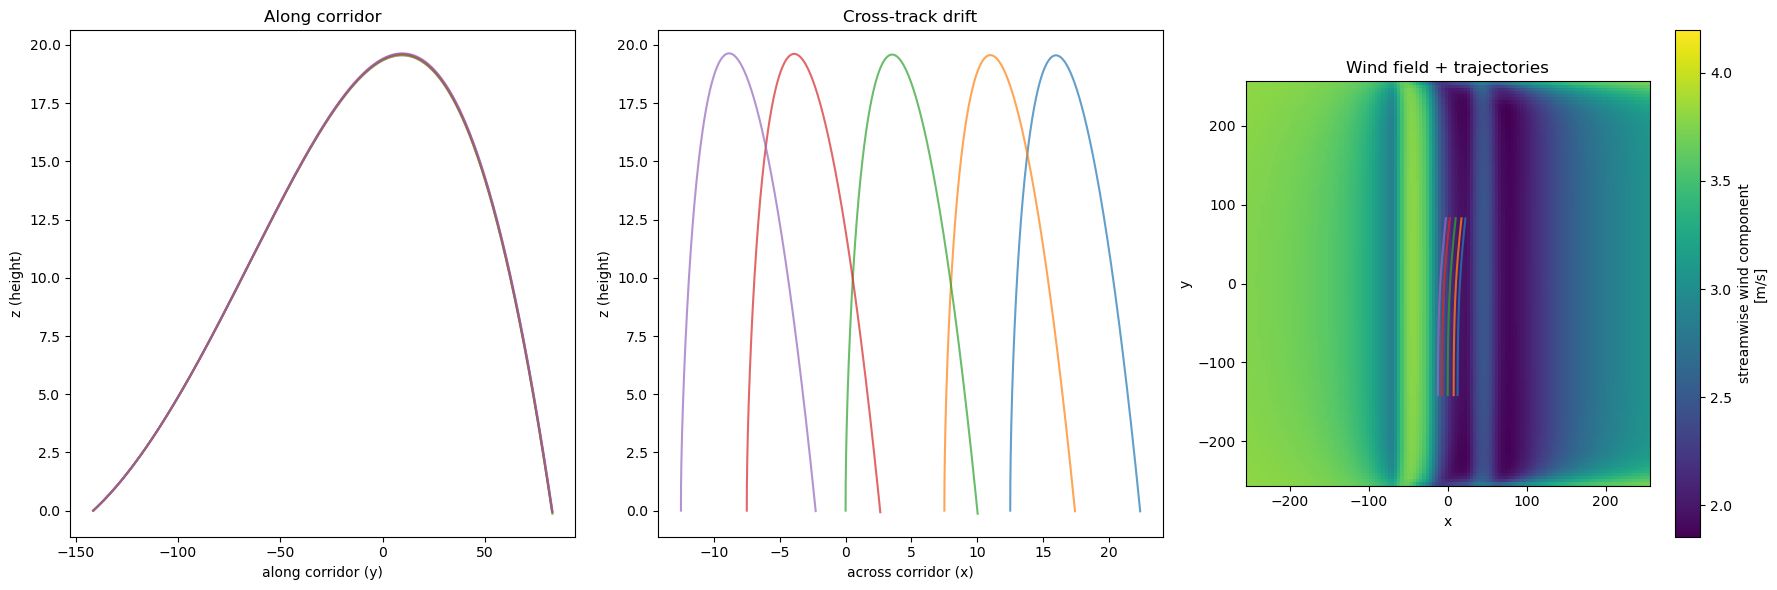

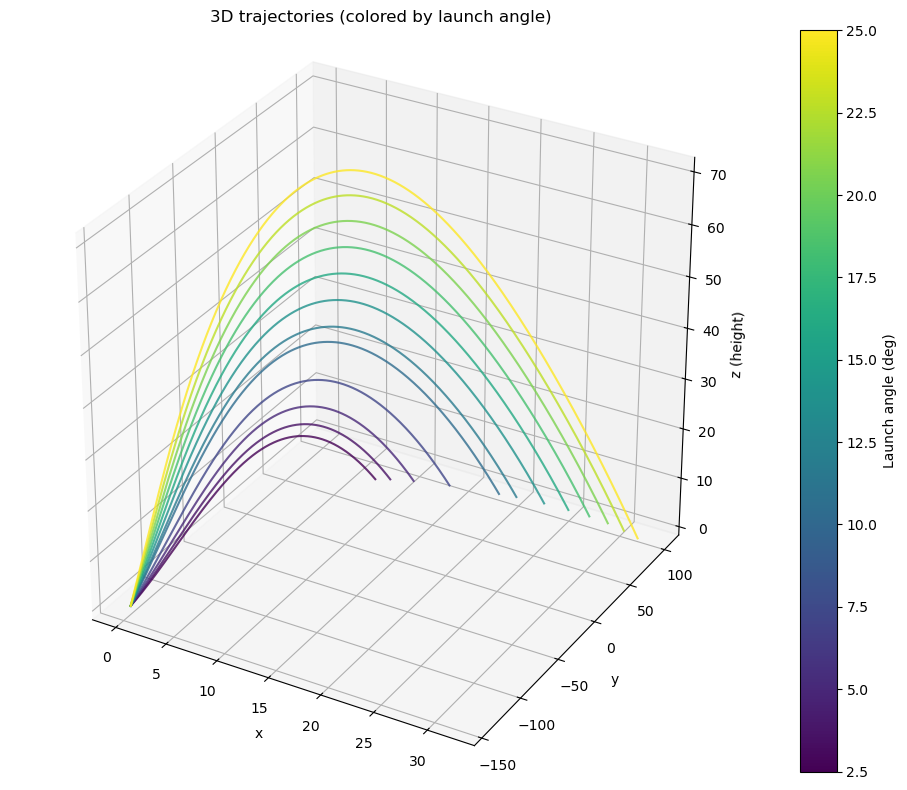

In [238]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from Tracer import WindField, Trajectory

# -----------------------
# Load wind field
# -----------------------
filepath = r'C:\Users\allpe\OneDrive\Skrivebord\DTU\Bachelorprojekt\Bachelor_legeplads\demos\nc files\flowdata_corr_wd270.nc'

U_ref = 6
corr_wf = WindField(profile='rans', ds=filepath, U_ref=U_ref)

# -----------------------
# Parameters
# -----------------------
r = 100
dist = np.sqrt(r**2 + r**2)
dt = 0.01
shot_speed = 76.44384
shot_spin = 2545
spin_axis = 0
orientation = 90

# -----------------------
# Ensembles
# -----------------------
rel_corr_pos_values = [-25, -15, 0, 15, 25]
launch_angles = [2.5, 3.5 ,5, 7.22, 10.4, 11.67, 13.89, 16.11, 18.33, 20.56, 22.78, 25]

# =========================================================
# 1. BASE CORRIDOR ENSEMBLE (fixed angle)
# =========================================================
trajectories_base = []

for i in range(len(rel_corr_pos_values)):

    component = rel_corr_pos_values[i] / 2
    P0 = np.array([-component, -dist, 0])

    traj = Trajectory(
        ball_speed=shot_speed,
        launch_angle=4.6,
        spin_rate=shot_spin,
        spin_axis=spin_axis,
        wind=corr_wf,
        orientation=orientation,
        P0=P0
    )

    traj.solve(solver='euler', dt=dt)
    trajectories_base.append(traj)

# =========================================================
# 2. 2D PLOTS (corridor view)
# =========================================================
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# Along corridor (y-z)
for traj in trajectories_base:
    ax[0].plot(traj.p[:, 1], traj.p[:, 2], alpha=0.7)

ax[0].set_xlabel('along corridor (y)')
ax[0].set_ylabel('z (height)')
ax[0].set_title('Along corridor')

# Cross-track (x-z)
for traj in trajectories_base:
    ax[1].plot(traj.p[:, 0], traj.p[:, 2], alpha=0.7)

ax[1].set_xlabel('across corridor (x)')
ax[1].set_ylabel('z (height)')
ax[1].set_title('Cross-track drift')

# Top-down + wind field
U_slice = corr_wf.ds.U.isel(z=10)

U_slice.plot(
    x="x",
    y="y",
    ax=ax[2],
    cmap="viridis",
    add_colorbar=True
)

for traj in trajectories_base:
    ax[2].plot(traj.p[:, 0], traj.p[:, 1], alpha=0.8)

ax[2].set_xlim(-256, 256)
ax[2].set_ylim(-256, 256)
ax[2].set_aspect('equal', adjustable='box')
ax[2].set_xlabel('x')
ax[2].set_ylabel('y')
ax[2].set_title('Wind field + trajectories')

plt.tight_layout()
plt.show()

# =========================================================
# 3. 3D MULTI-ANGLE SIMULATION
# =========================================================
trajectories_3d = []

for ang in launch_angles:
#    for i in range(len(rel_corr_pos_values)):

#       component = rel_corr_pos_values[i] / 2
        P0 = np.array([0, -dist, 0])

        traj = Trajectory(
            ball_speed=shot_speed,
            launch_angle=ang,
            spin_rate=shot_spin,
            spin_axis=spin_axis,
            wind=corr_wf,
            orientation=orientation,
            P0=P0
        )

        traj.solve(solver='euler', dt=dt)
        trajectories_3d.append((ang, traj))

# =========================================================
# 4. 3D PLOT (colored by launch angle)
# =========================================================
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

angles = np.array([a for a, _ in trajectories_3d])
norm = plt.Normalize(angles.min(), angles.max())
cmap = plt.cm.viridis

for ang, traj in trajectories_3d:
    ax.plot(
        traj.p[:, 0],
        traj.p[:, 1],
        traj.p[:, 2],
        color=cmap(norm(ang)),
        alpha=0.8
    )

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z (height)')
ax.set_title('3D trajectories (colored by launch angle)')

ax.set_box_aspect([1, 1, 1])

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Launch angle (deg)')

plt.tight_layout()
plt.show()

import plotly.graph_objects as go
import numpy as np

fig = go.Figure()

angles = np.array([a for a, _ in trajectories_3d])
norm = (angles - angles.min()) / (angles.max() - angles.min())

for i, (ang, traj) in enumerate(trajectories_3d):

    fig.add_trace(go.Scatter3d(
        x=traj.p[:, 0],
        y=traj.p[:, 1],
        z=traj.p[:, 2],
        mode='lines',
        line=dict(
            color=ang,
            colorscale='Viridis',
            cmin=angles.min(),
            cmax=angles.max(),
            width=4
        ),
        name=f"{ang:.2f}°"
    ))

fig.update_layout(
    title="3D Ball Trajectories (interactive)",
    scene=dict(
        xaxis_title='x',
        yaxis_title='y',
        zaxis_title='z',
        aspectmode='cube'
    ),
    width=900,
    height=700
)

fig.show()